# Phase 8 — Notebook 3: Pre-training Objectives — How Models Learn Language

> **The Core Question**: How does a model learn to understand language without any labeled data? The answer is self-supervised learning — designing tasks where the text itself provides the training signal. This notebook explains the two pivotal training objectives: **MLM** (BERT's approach) and **CLM** (GPT's approach).

---

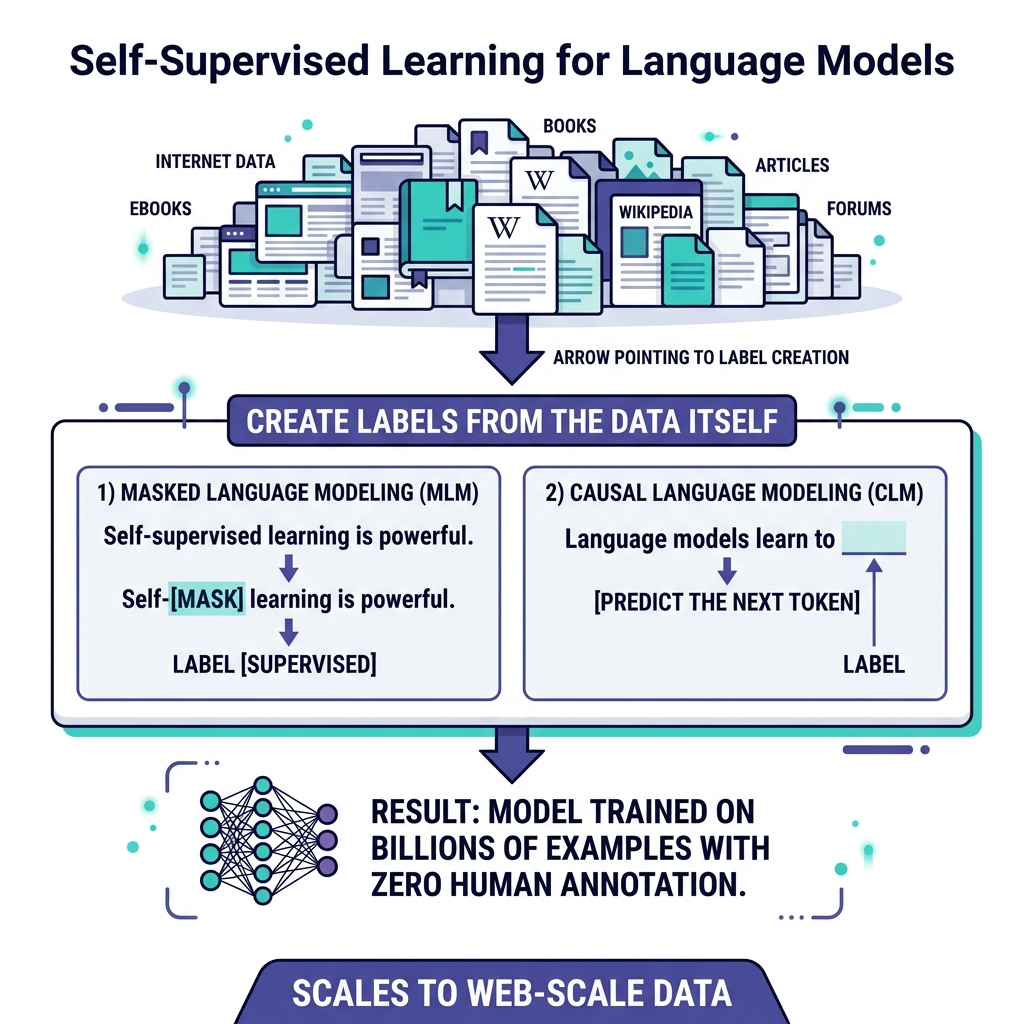

*Figure 1: Self-Supervised Learning — The data labels itself, enabling training on web-scale text with zero human annotation*



## 1. Self-Supervised Learning: Labels from the Data Itself

Traditional supervised learning requires humans to manually label data. Self-supervised learning is a breakthrough that creates the labels automatically from the data structure:

```
Raw text: 'The cat sat on the mat'

MLM Task (BERT):
  Input:  'The cat [MASK] on the mat'  ← mask a random word
  Label:  'sat'                         ← original word is the label!

CLM Task (GPT):
  Input:  'The cat sat on the'           ← all words up to position N
  Label:  'mat'                          ← next word is the label!
```

**This is profound**: we don't need a single human annotation. The entire internet — trillions of words — becomes a labeled training set. The model must develop real language understanding to solve these tasks well.

---

## 2. Masked Language Modeling (MLM) — BERT's Pre-training Objective

MLM was inspired by the 'Cloze' task from educational psychology — filling in blanks in a sentence. BERT's version has a specific strategy:

### The 15% Masking Rule
15% of tokens in each sequence are selected as candidates. Of those:

| Decision | Probability | What Happens |
|---|---|---|
| Replace with `[MASK]` | 80% | Model must predict the original token |
| Replace with random token | 10% | Prevents model from assuming `[MASK]` = signal |
| Keep original token | 10% | Forces model to produce good representations for all tokens |

### Why the 80/10/10 Split?
If we always used `[MASK]`, the model would only produce good representations for masked positions. During fine-tuning and inference, *every* token needs a good representation. The 10% random + 10% unchanged forces the model to always compute a rich representation for every token, not just the masked ones.

### The Bidirectional Advantage
The key insight: to predict a masked word, BERT can look at **all surrounding context — both left AND right**. The sentence "The cat [MASK] on the mat" lets BERT look at both "The cat" and "on the mat" simultaneously — this bidirectional view gives much richer context than reading left-to-right.

---

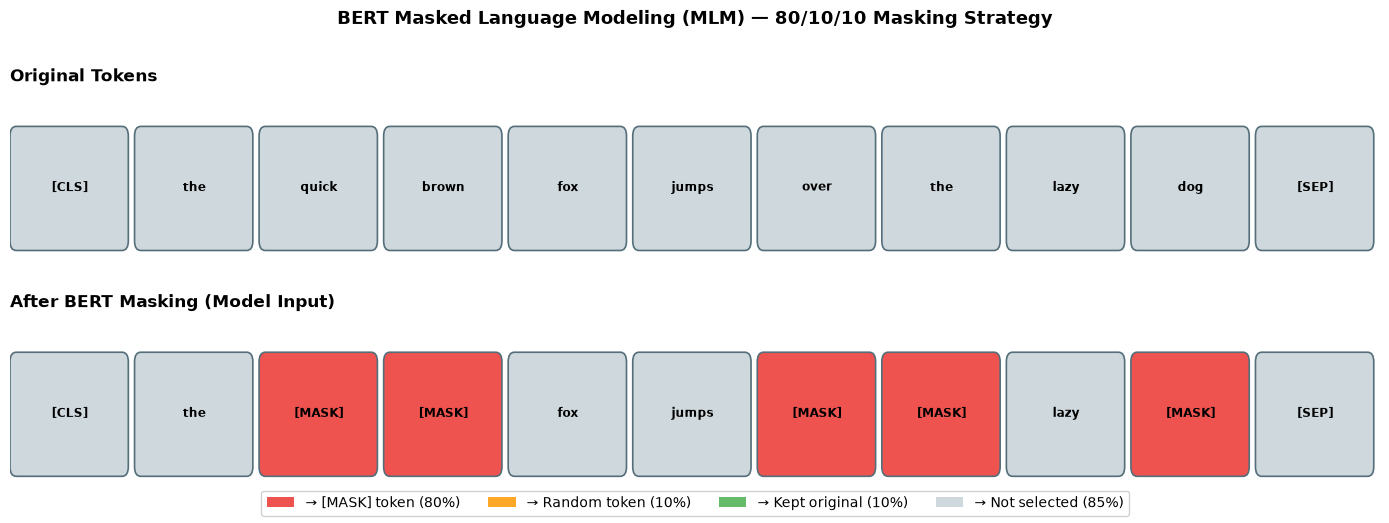


Target: model must predict the ORIGINAL token for all selected positions.
The model computes predictions for ALL tokens simultaneously (bidirectional).


In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
random.seed(42)

# Simulate BERT's 15% masking strategy
def apply_bert_masking(tokens, mask_prob=0.15, vocab_size=30522):
    """Simulate BERT's masking strategy on a token list."""
    masked_tokens = tokens.copy()
    labels = [-100] * len(tokens)  # -100 = ignore in loss (unmasked positions)
    mask_actions = ['original'] * len(tokens)
    
    for i, token in enumerate(tokens):
        if token in ['[CLS]', '[SEP]', '[PAD]']:  # never mask special tokens
            continue
        if random.random() < mask_prob:
            labels[i] = i  # track this position
            dice = random.random()
            if dice < 0.80:
                masked_tokens[i] = '[MASK]'
                mask_actions[i] = 'masked'
            elif dice < 0.90:
                masked_tokens[i] = f'random_tok_{random.randint(1000,9000)}'
                mask_actions[i] = 'randomized'
            else:
                mask_actions[i] = 'kept_original'  # unchanged but still in loss
    return masked_tokens, labels, mask_actions

# Example sentence
tokens = ['[CLS]', 'the', 'quick', 'brown', 'fox', 'jumps', 'over', 'the', 'lazy', 'dog', '[SEP]']
masked_tokens, labels, actions = apply_bert_masking(tokens, mask_prob=0.35)  # higher for demo

# Visualize
fig, axes = plt.subplots(2, 1, figsize=(14, 5))

colors_orig = ['#CFD8DC'] * len(tokens)
colors_masked = []
for action in actions:
    if action == 'masked': colors_masked.append('#EF5350')
    elif action == 'randomized': colors_masked.append('#FFA726')
    elif action == 'kept_original': colors_masked.append('#66BB6A')
    else: colors_masked.append('#CFD8DC')

for ax, token_list, color_list, title in [
    (axes[0], tokens, colors_orig, 'Original Tokens'),
    (axes[1], masked_tokens, colors_masked, 'After BERT Masking (Model Input)'),
]:
    ax.set_xlim(0, len(token_list))
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.set_title(title, fontweight='bold', fontsize=12, loc='left', pad=5)
    for j, (tok, col) in enumerate(zip(token_list, color_list)):
        rect = mpatches.FancyBboxPatch((j+0.05, 0.2), 0.85, 0.55,
                                        boxstyle='round,pad=0.05',
                                        facecolor=col, edgecolor='#546E7A', lw=1.2)
        ax.add_patch(rect)
        ax.text(j+0.48, 0.48, tok, ha='center', va='center', fontsize=8.5, fontweight='bold')

# Legend
legend_elements = [
    mpatches.Patch(facecolor='#EF5350', label='→ [MASK] token (80%)'),
    mpatches.Patch(facecolor='#FFA726', label='→ Random token (10%)'),
    mpatches.Patch(facecolor='#66BB6A', label='→ Kept original (10%)'),
    mpatches.Patch(facecolor='#CFD8DC', label='→ Not selected (85%)'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=4, fontsize=10, framealpha=0.9)
plt.suptitle("BERT Masked Language Modeling (MLM) — 80/10/10 Masking Strategy", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(r'outputs/p8_mlm_masking_demo.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nTarget: model must predict the ORIGINAL token for all selected positions.')
print('The model computes predictions for ALL tokens simultaneously (bidirectional).')

## 3. Next Sentence Prediction (NSP) — BERT's Secondary Objective

In addition to MLM, the original BERT paper included a second pre-training task: **Next Sentence Prediction (NSP)**.

### How NSP Works
The model receives two sentences and must predict whether sentence B actually follows sentence A in the original document:

```
Positive Example (IsNext = True):
  [CLS] The dog sat on the mat [SEP] It wagged its tail happily [SEP]
  Label: IsNext

Negative Example (IsNext = False):
  [CLS] The dog sat on the mat [SEP] The stock market fell 3% today [SEP]
  Label: NotNext  (randomly sampled from a different document)
```

50% of training pairs are genuine consecutive sentences; 50% are random pairings.

### Why NSP Was Added
The original motivation was to help the model understand document-level coherence — useful for tasks like question answering (where the answer must logically follow from the question) and natural language inference.

### The NSP Controversy
Later research (RoBERTa, 2019) found that **removing NSP actually improved BERT's performance** on downstream tasks. The hypothesis: NSP training causes the model to learn topic prediction (since negative examples come from different documents = different topics) rather than genuine sentence coherence. RoBERTa trains with MLM only.

---

In [2]:
# Simulate NSP data construction
import random
random.seed(42)

# Simulated document corpus
documents = [
    [
        "The researchers published their findings in Nature.",
        "The study analyzed over 10,000 patient samples.",
        "Results showed a 40% improvement in diagnostic accuracy.",
        "This could transform how diseases are detected early.",
    ],
    [
        "The company announced record quarterly profits.",
        "Revenue grew by 23% year-over-year in all regions.",
        "The CEO credited investments in AI infrastructure.",
        "Shares rose 8% in after-hours trading.",
    ],
    [
        "The national team qualified for the World Cup.",
        "They defeated the defending champions 2-1 in a tense final.",
        "Fans celebrated throughout the city until midnight.",
    ],
]

def create_nsp_pairs(documents, num_pairs=6):
    pairs = []
    all_sentences = [s for doc in documents for s in doc]
    for _ in range(num_pairs):
        # Pick a random document and a random sentence (not the last)
        doc = random.choice(documents)
        if len(doc) < 2:
            continue
        idx = random.randint(0, len(doc) - 2)
        sent_a = doc[idx]
        # 50% chance: genuine next sentence
        if random.random() < 0.5:
            sent_b = doc[idx + 1]
            label = 'IsNext ✅'
        else:
            # Random sentence from any other document
            other = random.choice([s for s in all_sentences if s not in doc])
            sent_b = other
            label = 'NotNext ❌'
        pairs.append((sent_a, sent_b, label))
    return pairs

pairs = create_nsp_pairs(documents)
print('NSP Training Pair Examples:')
print('=' * 70)
for i, (a, b, label) in enumerate(pairs):
    print(f'\nPair {i+1} — Label: {label}')
    print(f'  Sentence A: "{a}"')
    print(f'  Sentence B: "{b}"')

NSP Training Pair Examples:

Pair 1 — Label: IsNext ✅
  Sentence A: "The national team qualified for the World Cup."
  Sentence B: "They defeated the defending champions 2-1 in a tense final."

Pair 2 — Label: IsNext ✅
  Sentence A: "The company announced record quarterly profits."
  Sentence B: "Revenue grew by 23% year-over-year in all regions."

Pair 3 — Label: NotNext ❌
  Sentence A: "The national team qualified for the World Cup."
  Sentence B: "The study analyzed over 10,000 patient samples."

Pair 4 — Label: IsNext ✅
  Sentence A: "They defeated the defending champions 2-1 in a tense final."
  Sentence B: "Fans celebrated throughout the city until midnight."

Pair 5 — Label: IsNext ✅
  Sentence A: "The researchers published their findings in Nature."
  Sentence B: "The study analyzed over 10,000 patient samples."

Pair 6 — Label: NotNext ❌
  Sentence A: "The national team qualified for the World Cup."
  Sentence B: "The CEO credited investments in AI infrastructure."


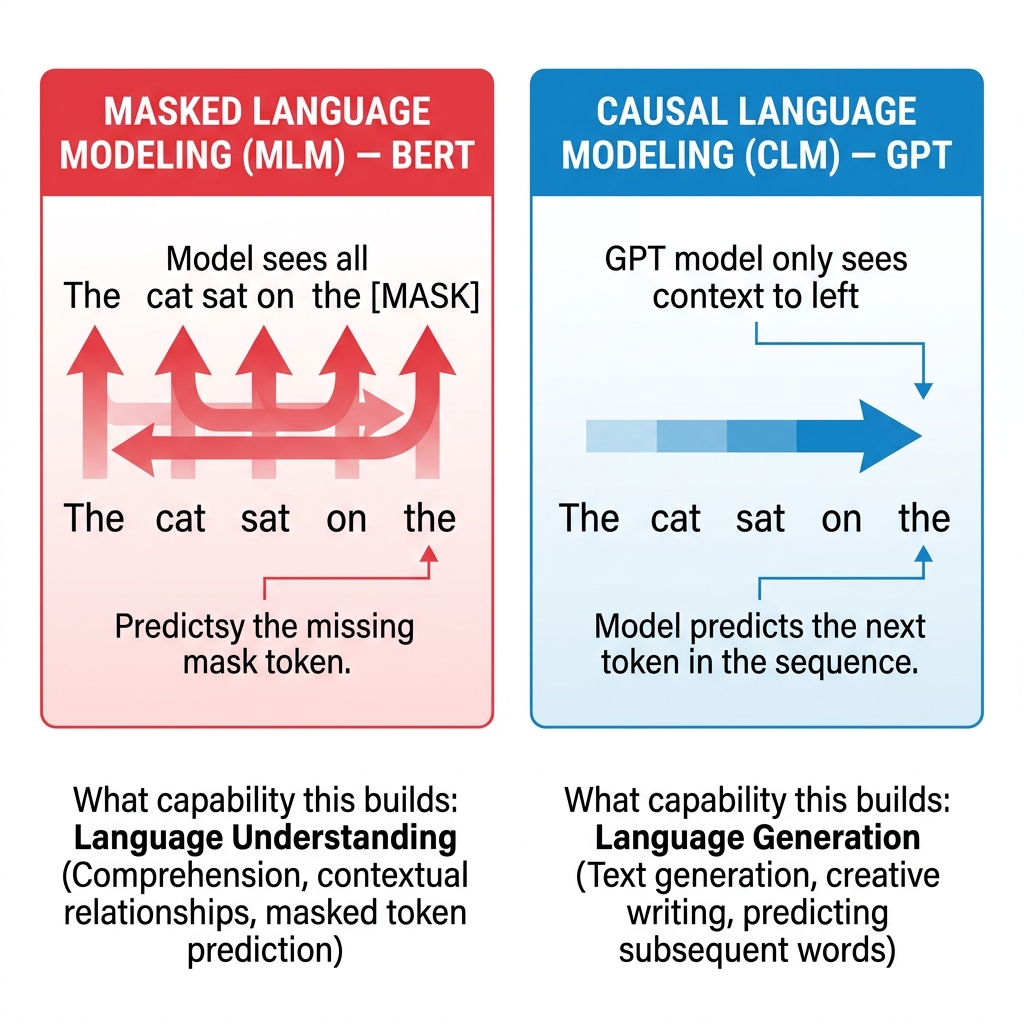

*Figure 2: MLM vs CLM — The bidirectional understanding objective (BERT) versus the autoregressive generation objective (GPT)*



## 4. Causal Language Modeling (CLM) — GPT's Pre-training Objective

GPT takes an entirely different approach: **predict the next token given all preceding tokens**. This is the classic language modeling objective — the same task used by n-gram models, but now implemented with a Transformer decoder.

```
Training sequence: 'The quick brown fox jumps over'

Step 1: Input: [The]                    → Predict: quick
Step 2: Input: [The, quick]              → Predict: brown
Step 3: Input: [The, quick, brown]       → Predict: fox
Step 4: Input: [The, quick, brown, fox]  → Predict: jumps
...and so on
```

**Key constraint**: At each step, the model can ONLY look at tokens to the LEFT (previous tokens). It cannot peek at future tokens. This is enforced by the **causal attention mask** (triangular mask) from Phase 7.

### Why Causal? Why Not Bidirectional?
Causal language modeling trains a model that is naturally suited for **generation** — given a context, predict what comes next. This is the fundamental task for:
- Text completion
- Creative writing
- Code generation
- Dialogue and chatbots
- Any task where you generate output token by token

---

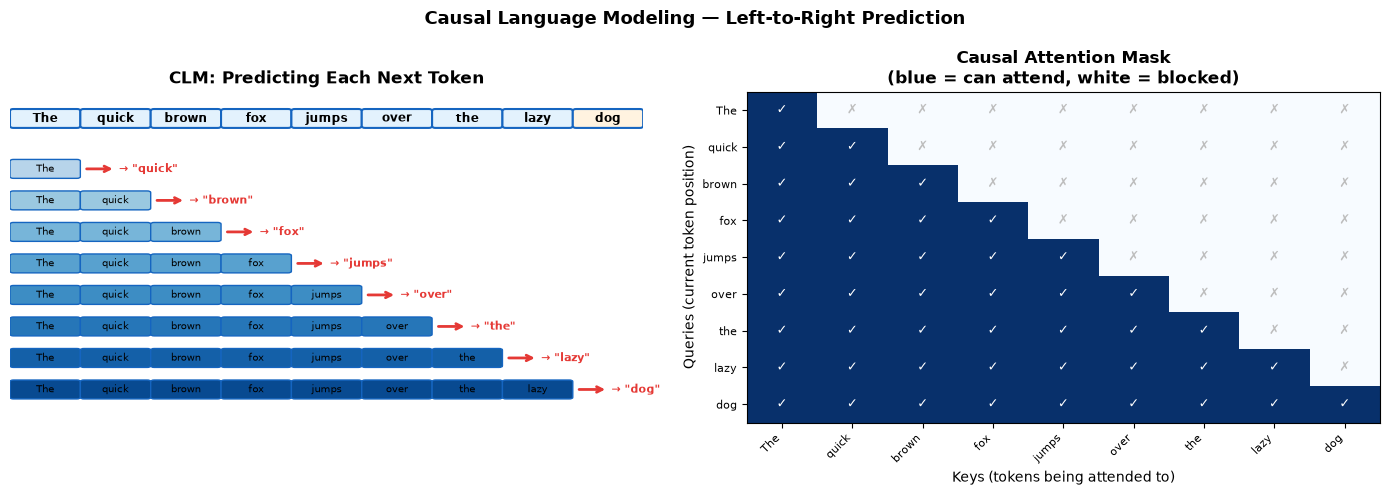


The triangular mask ensures: when predicting token at position N,
the model can only attend to positions 0 through N-1 (never the future).


In [3]:
# Visualize the Causal Language Model training process
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

tokens = ['The', 'quick', 'brown', 'fox', 'jumps', 'over', 'the', 'lazy', 'dog']
n = len(tokens)

# Build causal mask: 1 = can attend, 0 = masked
causal_mask = np.tril(np.ones((n, n)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: CLM prediction steps
ax1 = axes[0]
ax1.set_xlim(-0.5, n - 0.5)
ax1.set_ylim(-1, n + 0.5)
ax1.axis('off')
ax1.set_title('CLM: Predicting Each Next Token', fontweight='bold', fontsize=12)

for i, tok in enumerate(tokens):
    # Input tokens (left to right)
    bg = '#E3F2FD' if i < n-1 else '#FFF3E0'
    rect = mpatches.FancyBboxPatch((i - 0.45, n - 0.6), 0.9, 0.5,
                                    boxstyle='round,pad=0.05', facecolor=bg,
                                    edgecolor='#1565C0', lw=1.5)
    ax1.add_patch(rect)
    ax1.text(i, n - 0.35, tok, ha='center', va='center', fontsize=8.5, fontweight='bold')

# Show prediction steps
step_colors = plt.cm.Blues(np.linspace(0.3, 0.9, n-1))
for step in range(n - 1):
    y = n - step - 2.2
    for j in range(step + 1):
        rect = mpatches.FancyBboxPatch((j - 0.45, y), 0.9, 0.5,
                                        boxstyle='round,pad=0.05',
                                        facecolor=step_colors[step],
                                        edgecolor='#1565C0', lw=1)
        ax1.add_patch(rect)
        ax1.text(j, y + 0.25, tokens[j], ha='center', va='center', fontsize=7.5)
    # Prediction arrow
    ax1.annotate('', xy=(step + 1, y + 0.25), xytext=(step + 0.55, y + 0.25),
                arrowprops=dict(arrowstyle='->', color='#E53935', lw=2))
    ax1.text(step + 1 + 0.05, y + 0.25, f'→ "{tokens[step+1]}"',
            ha='left', va='center', fontsize=8, color='#E53935', fontweight='bold')

# Right: Causal attention mask
ax2 = axes[1]
im = ax2.imshow(causal_mask, cmap='Blues', aspect='auto', vmin=0, vmax=1)
ax2.set_xticks(range(n))
ax2.set_yticks(range(n))
ax2.set_xticklabels(tokens, rotation=45, ha='right', fontsize=8)
ax2.set_yticklabels(tokens, fontsize=8)
ax2.set_xlabel('Keys (tokens being attended to)', fontsize=10)
ax2.set_ylabel('Queries (current token position)', fontsize=10)
ax2.set_title('Causal Attention Mask\n(blue = can attend, white = blocked)', fontweight='bold', fontsize=12)
# Annotate
for i in range(n):
    for j in range(n):
        val = '✓' if causal_mask[i,j] == 1 else '✗'
        color = 'white' if causal_mask[i,j] == 1 else '#BDBDBD'
        ax2.text(j, i, val, ha='center', va='center', fontsize=9, color=color)

plt.suptitle('Causal Language Modeling — Left-to-Right Prediction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(r'outputs/p8_clm_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nThe triangular mask ensures: when predicting token at position N,')
print('the model can only attend to positions 0 through N-1 (never the future).')

## 5. MLM vs. CLM: The Fundamental Architectural Trade-off

The choice between MLM and CLM is not just a training detail — it determines the model's fundamental capabilities.

| Dimension | MLM (BERT) | CLM (GPT) |
|---|---|---|
| **Context access** | Bidirectional (left AND right) | Unidirectional (left only) |
| **Ideal task** | Understanding: classification, NER, QA | Generation: completion, dialogue, code |
| **Training signal** | Predict masked tokens | Predict next token |
| **Inference** | All positions computed in ONE pass | Token generated ONE at a time |
| **Architecture** | Transformer Encoder stack | Transformer Decoder stack |
| **Representative** | BERT, RoBERTa, ALBERT | GPT-2, GPT-3, GPT-4, LLaMA |

### Why Can't BERT Generate Text?
BERT was trained to look at full sequences. At inference time, if you want to generate text token-by-token, you'd need to construct a `[MASK]` sequence — but BERT doesn't have a natural mechanism to generate *new* tokens that weren't in the input. GPT is inherently generative because it was trained to produce the *next* token.

### Why Can't GPT Answer Fill-in-the-Blank Questions as Well?
GPT only sees left context. To understand "The `___` sat on the mat where the cat was happy", GPT can only use what comes before the blank. BERT uses "the mat where the cat was happy" as well — a crucial advantage for comprehension tasks.

---

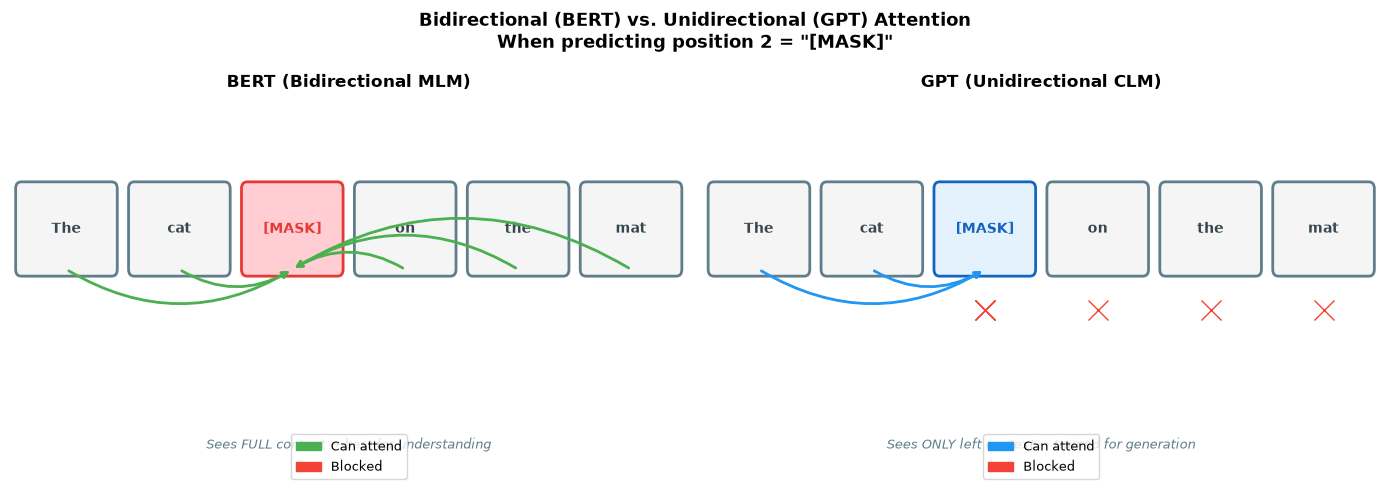

BERT uses ALL 5 surrounding tokens to predict [MASK].
GPT-style model can only use the 2 tokens to the LEFT.


In [4]:
# Visualize the bidirectional vs unidirectional attention difference
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

tokens = ['The', 'cat', '[MASK]', 'on', 'the', 'mat']
n = len(tokens)
mask_pos = 2  # '[MASK]' position

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax_idx, (title, model, use_bidirectional) in enumerate([
    ('BERT (Bidirectional MLM)', 'bert', True),
    ('GPT (Unidirectional CLM)', 'gpt', False),
]):
    ax = axes[ax_idx]
    ax.set_xlim(-0.5, n - 0.5)
    ax.set_ylim(-0.8, 2)
    ax.axis('off')
    ax.set_title(title, fontweight='bold', fontsize=12, pad=15)

    target_color = '#E53935' if model == 'bert' else '#1565C0'

    for i, tok in enumerate(tokens):
        # Token box
        if i == mask_pos:
            fc = '#FFCDD2' if model == 'bert' else '#E3F2FD'
            ec = target_color
        else:
            fc = '#F5F5F5'
            ec = '#607D8B'
        rect = mpatches.FancyBboxPatch((i-0.4, 0.8), 0.8, 0.6,
                                        boxstyle='round,pad=0.05',
                                        facecolor=fc, edgecolor=ec, lw=2)
        ax.add_patch(rect)
        ax.text(i, 1.1, tok, ha='center', va='center', fontsize=10,
                fontweight='bold', color=target_color if i == mask_pos else '#37474F')

    # Draw attention arrows to the mask position
    for i in range(n):
        if i == mask_pos:
            continue
        can_attend = use_bidirectional or (i < mask_pos)
        if can_attend:
            color = '#4CAF50' if use_bidirectional else '#2196F3'
            ax.annotate('', xy=(mask_pos, 0.8), xytext=(i, 0.8),
                        arrowprops=dict(arrowstyle='->', color=color, lw=2,
                                        connectionstyle='arc3,rad=0.3'))
        else:
            ax.plot([i, mask_pos], [0.5, 0.5], 'x', color='#F44336', markersize=15, lw=3)

    # Legend
    attend_patch = mpatches.Patch(color='#4CAF50' if use_bidirectional else '#2196F3',
                                  label='Can attend')
    block_patch = mpatches.Patch(color='#F44336', label='Blocked')
    ax.legend(handles=[attend_patch, block_patch], loc='lower center', fontsize=9)

    # Label
    info = ('Sees FULL context → best for understanding' if use_bidirectional
            else 'Sees ONLY left context → trained for generation')
    ax.text(n/2 - 0.5, -0.5, info, ha='center', va='center',
            fontsize=9, style='italic', color='#607D8B')

plt.suptitle('Bidirectional (BERT) vs. Unidirectional (GPT) Attention\nWhen predicting position 2 = "[MASK]"',
            fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(r'outputs/p8_bidirectional_vs_unidirectional.png', dpi=150, bbox_inches='tight')
plt.show()
print('BERT uses ALL 5 surrounding tokens to predict [MASK].')
print('GPT-style model can only use the 2 tokens to the LEFT.')

## 6. Training Data: What Models Are Pre-trained On

The quality and diversity of pre-training data determines what a model knows about the world:

| Model | Dataset | Size | Sources |
|---|---|---|---|
| **BERT-Base** | BookCorpus + Wikipedia | ~16 GB | 11,038 books + English Wikipedia |
| **RoBERTa** | CC-News + OpenWebText + Books + Wikipedia | ~160 GB | Larger, better curated |
| **GPT-2** | WebText | ~40 GB | 45M Reddit links with ≥3 karma |
| **GPT-3** | Common Crawl + Books + Wikipedia | ~570 GB | Filtered and deduplicated web text |
| **LLaMA-3** | The Pile + custom data | ~15 TB | Diverse, high-quality sources |

### The Scaling Hypothesis
Research has consistently shown that:
1. **More data** → better language understanding
2. **More parameters** → more capacity to store knowledge
3. **More compute** → better optimization

The *Chinchilla* paper (2022) found the optimal scaling law: for a given compute budget, you should train a *smaller model on more tokens* rather than a larger model on fewer tokens. This insight drove the architecture choices of modern efficient LLMs.

---

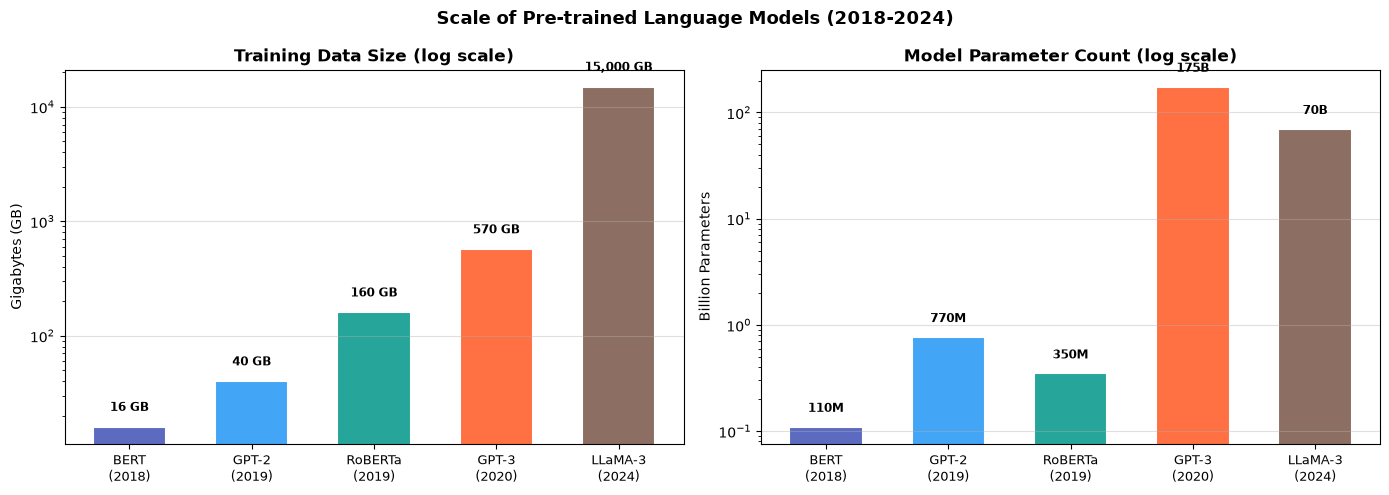

Data and model scale increased by 1,000x in 6 years.
This scale is a core driver of emergent capabilities.


In [5]:
# Visualize training data scale comparison
import matplotlib.pyplot as plt
import numpy as np

models = ['BERT\n(2018)', 'GPT-2\n(2019)', 'RoBERTa\n(2019)', 'GPT-3\n(2020)', 'LLaMA-3\n(2024)']
data_gb = [16, 40, 160, 570, 15000]
params_b = [0.11, 0.77, 0.35, 175, 70]

x = np.arange(len(models))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training data size
bars1 = axes[0].bar(x, data_gb, color=['#5C6BC0','#42A5F5','#26A69A','#FF7043','#8D6E63'],
                    width=0.6, edgecolor='white', lw=1.5)
axes[0].set_yscale('log')
axes[0].set_title('Training Data Size (log scale)', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Gigabytes (GB)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, fontsize=9)
for bar, val in zip(bars1, data_gb):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.3,
                f'{val:,} GB', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
axes[0].grid(axis='y', alpha=0.4)

# Parameter count
bars2 = axes[1].bar(x, params_b, color=['#5C6BC0','#42A5F5','#26A69A','#FF7043','#8D6E63'],
                    width=0.6, edgecolor='white', lw=1.5)
axes[1].set_yscale('log')
axes[1].set_title('Model Parameter Count (log scale)', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Billion Parameters')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, fontsize=9)
for bar, val in zip(bars2, params_b):
    label = f'{val}B' if val >= 1 else f'{int(val*1000)}M'
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.3,
                label, ha='center', va='bottom', fontsize=8.5, fontweight='bold')
axes[1].grid(axis='y', alpha=0.4)

plt.suptitle('Scale of Pre-trained Language Models (2018-2024)',
            fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(r'outputs/p8_model_scaling.png', dpi=150, bbox_inches='tight')
plt.show()
print('Data and model scale increased by 1,000x in 6 years.')
print('This scale is a core driver of emergent capabilities.')

## 7. Summary — The Two Philosophies of Language Learning

| | MLM (BERT Family) | CLM (GPT Family) |
|---|---|---|
| **Core task** | Fill in masked tokens | Predict the next token |
| **Context** | Full bidirectional | Left-to-right only |
| **Strength** | Language *understanding* | Language *generation* |
| **Architecture** | Encoder stack | Decoder stack |
| **Secondary task** | NSP (now removed in RoBERTa) | None — CLM is sufficient |
| **Key models** | BERT, RoBERTa, ALBERT, DeBERTa | GPT-2, GPT-3, GPT-4, LLaMA |

Both objectives are self-supervised — they create labels from the data itself, enabling training on trillion-token corpora without any human annotation. This is what makes modern LLMs possible.

### 🚀 What's Next
Notebook 4 takes a deep architectural dive into **BERT** — examining every component from input embeddings to attention heads, and understanding what each layer actually learns.

---
*Phase 8, Notebook 3 of 10 — NLP From Scratch: Foundation to Advanced*